In [28]:
from typing import TypedDict , Annotated
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import AnyMessage , AIMessage , BaseMessage
from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt , Command
from dotenv import load_dotenv
from rich import print

In [17]:
load_dotenv()

True

In [18]:
llm = ChatMistralAI(model="mistral-small-2506")

In [19]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage] , add_messages]

In [20]:
def chat_node(state : ChatState):

# HITL CONCEPT: `interrupt` pauses the graph execution here.
# The state is saved to the checkpointer, and the payload is returned to the user.
# The graph will wait indefinitely until resumed with `Command(resume=...)`.
    decision = interrupt({
        "type": "approval",
        "reason" : "Model is about to answer a user question",
        "question" : state["messages"][-1].content,
        "instruction" : "Approve this question? yes / no"
    })

    if decision["approved"] == "no":
        return {"messages" : [AIMessage(content="Not Approved")]}

    else :
        response = llm.invoke(state["messages"])
        return {"messages" : [response]}

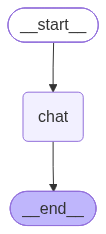

In [21]:
builder = StateGraph(ChatState)

builder.add_node("chat" , chat_node)

builder.add_edge(START , "chat")
builder.add_edge("chat" , END)

# HITL CONCEPT: `MemorySaver` is required for interrupts to work.
# It persists the graph state so it can be resumed later using a thread_id.
checkpointer = MemorySaver()

app = builder.compile(checkpointer=checkpointer)
app

In [22]:
# create a new thread id for this conversation
# thread_id is required when using a checkpointer to keep track of the specific conversation.
config = {"configurable" : {"thread_id" : "1234"}}

# Step 1 : User ask question
initial_input = {
    "messages" : [
        ("user" , "Explain gradient descnt is very simple terms")
    ]
} 

# Invoke the graph for the first time
result = app.invoke(initial_input , config=config)

In [23]:
result

{'messages': [HumanMessage(content='Explain gradient descnt is very simple terms', additional_kwargs={}, response_metadata={}, id='91b5fade-4a32-4d69-9c9a-7dff1f8433b1')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question', 'question': 'Explain gradient descnt is very simple terms', 'instruction': 'Approve this question? yes / no'}, id='ee66fe2d2f6ec1e50aa0cd8de6fc0330')]}

In [24]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question',
 'question': 'Explain gradient descnt is very simple terms',
 'instruction': 'Approve this question? yes / no'}

In [25]:
user_input = input(f"\nBackend Message - {message} \n Approve this question? (y/n)")

In [26]:
final_result = app.invoke(
# HITL CONCEPT: `Command(resume=...)` resumes the paused graph.
# The value passed to resume becomes the return value of the `interrupt` call.
    Command(resume={"approved": user_input}),
    config=config
)

In [29]:
print(final_result)

{
    'messages': [
        HumanMessage(
            content='Explain gradient descnt is very simple terms',
            additional_kwargs={},
            response_metadata={},
            id='91b5fade-4a32-4d69-9c9a-7dff1f8433b1'
        ),
        AIMessage(
            content='Imagine you\'re standing at the top of a hill covered in thick fog. Your goal is to reach the 
lowest point (the valley) to find the safest path down.\n\n**Gradient Descent** is like a smart way to walk 
downhill:\n\n1. **You look around** (check the slope) in all directions.\n2. **You take a step** in the direction 
where the ground is steepest downward.\n3. **You repeat** this process—look around, take a step—until you reach the
bottom.\n\n### Simple Analogy:\nThink of it like a lazy river ride:\n- The river (gradient) always flows 
downhill.\n- You (the algorithm) follow the river’s current (steepest slope) until you reach the calmest water (the
lowest point).\n\n### Key Idea:\nInstead of randomly walking down, you always move in the **steepest downward 
direction** (the negative gradient), which gets you to the bottom **faster**.\n\n### Real-World Use:\nIn machine 
learning, this helps a computer **learn** by adjusting its "answers" (like weights in a model) to minimize mistakes
(like climbing down a "mistake mountain").\n\n**In short:**\nGradient descent is a smart way to **find the lowest 
point by always moving downhill**. 🚶\u200d♂️⬇️',
            additional_kwargs={},
            response_metadata={
                'token_usage': {
                    'prompt_tokens': 24,
                    'total_tokens': 303,
                    'completion_tokens': 279,
                    'prompt_tokens_details': {'cached_tokens': 0},
                    'service_tier': 'standard'
                },
                'model_name': 'mistral-small-2506',
                'model': 'mistral-small-2506',
                'finish_reason': 'stop',
                'model_provider': 'mistralai'
            },
            id='lc_run--019fbd2d-1315-7d13-8dc0-50c5a6e93490-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 24, 'output_tokens': 279, 'total_tokens': 303}
        )
    ]
}